In [211]:
%load_ext IPython.extensions.autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [212]:
import sys
sys.path.append('../..')
from model import FinData
from model import train_valid_test_split
from model import CatboostFinModel
import catboost

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pandas as pd

In [12]:
data = FinData('../../datasets/Gazprom_1_min.csv')

cutoff_time_1 = dt.datetime(2024, 1, 1)
cutoff_time_2 = dt.datetime(2024, 12, 1)


data.restrict_time_down(cutoff_time_1)
data.restrict_time_up(cutoff_time_2)

In [ ]:
    # def insert_all(self, features_settings : dict | None = None, mini_features  = None):
    #     if features_settings == None:
    #         standart_windows = list(range(1, 20))
    #         self.insert_shifts_norms(standart_windows)
    #         self.insert_rolling_means(standart_windows)
    #         self.insert_exp_rolling_means(standart_windows)
    #         self.insert_rsi(standart_windows)
    #         self.insert_bollinger()
    #         self.insert_high_low_diff(standart_windows)

In [13]:
data.insert_exp_rolling_means([1])
data.df

        # for i in windows_ema:
        #     self.df[f'ema_{i}'] = (self.df['close']).ewm(span=i).mean()
        #     self.df[f'close_normed_ema_{i}'] = self.df['close']/self.df[f'ema_{i}']

,utc,open,close,high,low,volume,direction_binary_0,direction_binary_1,ema_1,close_normed_ema_1
0,2024-01-02 07:17:00,160.33,159.42,160.33,159.42,162,1,1,159.42,1.0
1,2024-01-02 07:18:00,160.29,160.28,160.29,159.42,56,0,0,160.28,1.0
2,2024-01-02 07:19:00,159.45,159.48,160.28,159.45,108,1,1,159.48,1.0
3,2024-01-02 07:20:00,159.48,160.17,160.19,159.47,54,0,0,160.17,1.0
4,2024-01-02 07:21:00,160.00,160.14,160.16,159.90,72,1,1,160.14,1.0
...,...,...,...,...,...,...,...,...,...,...
275653,2024-11-30 20:45:00,124.63,124.51,124.63,124.51,18,1,1,124.51,1.0
275654,2024-11-30 20:46:00,124.63,124.63,124.63,124.63,42,0,0,124.63,1.0
275655,2024-11-30 20:47:00,124.51,124.51,124.51,124.51,1,1,1,124.51,1.0
275656,2024-11-30 20:48:00,124.63,124.63,124.63,124.63,4,0,0,124.63,1.0


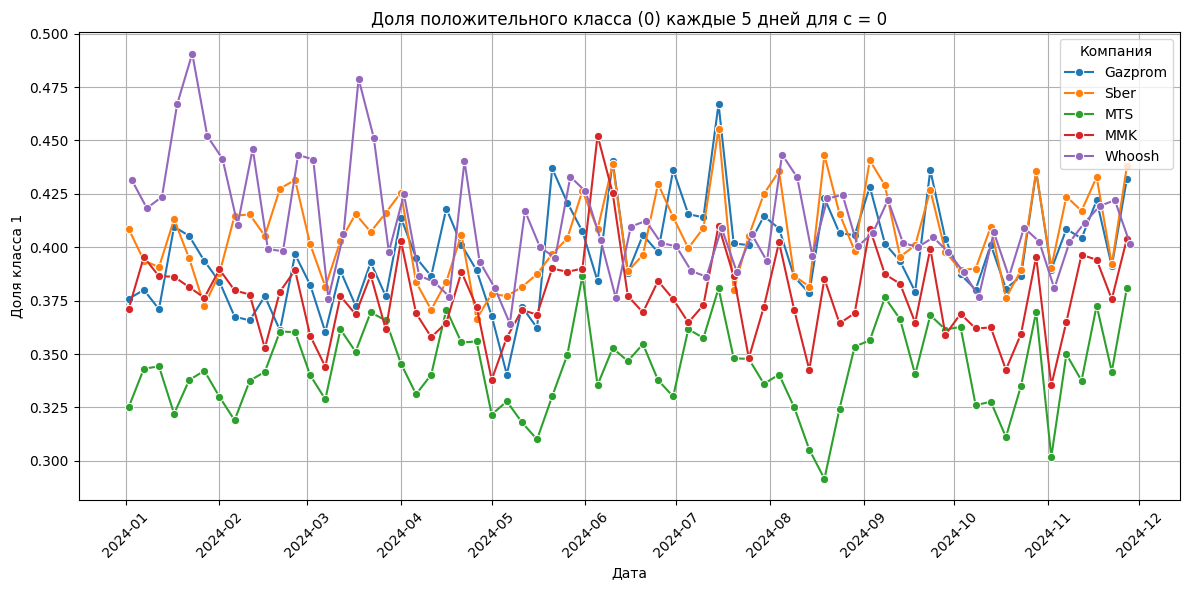

In [96]:
from pathlib import Path

# Параметры
companies = ['Gazprom', 'Sber', 'MTS', 'MMK', 'Whoosh']
path_base = Path('../../datasets')
cutoff_time_1 = dt.datetime(2024, 1, 1)
cutoff_time_2 = dt.datetime(2024, 12, 1)
window_size = pd.Timedelta(days=5)

# Результаты
all_balances = []

for company in companies:
    data = FinData(path_base / f'{company}_1_min.csv')
    data.restrict_time_down(cutoff_time_1)
    data.restrict_time_up(cutoff_time_2)
    
    df = data.df[['utc', 'direction_binary_0']].copy()
    df = df.set_index('utc').sort_index()

    # Резэмплируем по 5 дням: считаем среднее (будет ≈ доля единиц)
    balance = df['direction_binary_0'].resample(window_size).mean().reset_index()
    balance['company'] = company
    all_balances.append(balance)

# Объединяем в один DataFrame
balance_df = pd.concat(all_balances)

# Визуализация
plt.figure(figsize=(12, 6))
sns.lineplot(data=balance_df, x='utc', y='direction_binary_0', hue='company', marker='o')
plt.title('Доля положительного класса (0) каждые 5 дней для c = 0')
plt.ylabel('Доля класса 1')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title='Компания')
plt.show()

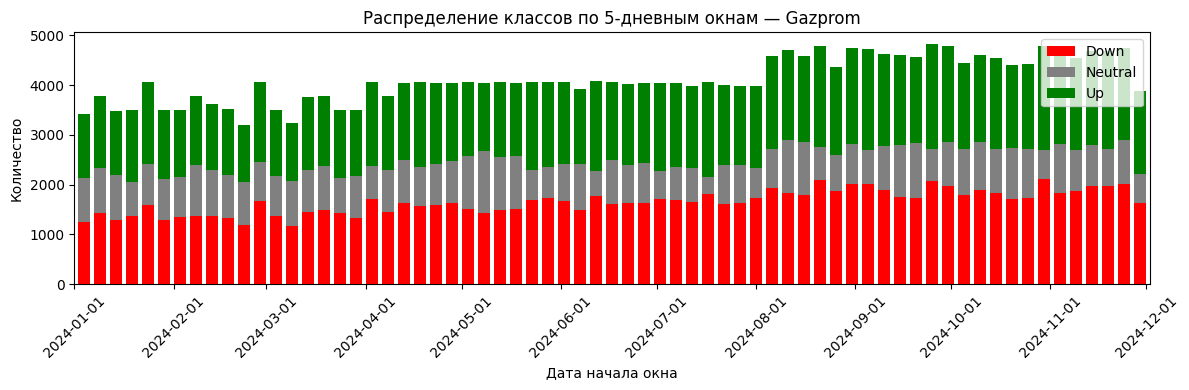

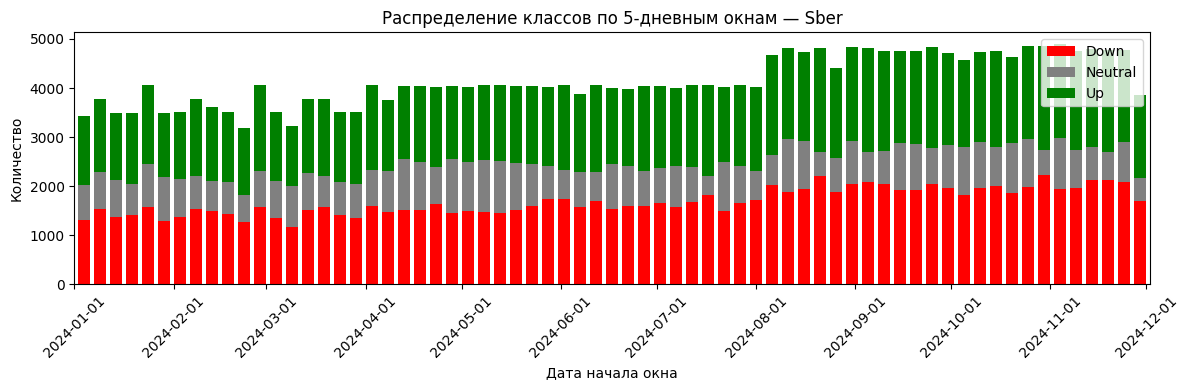

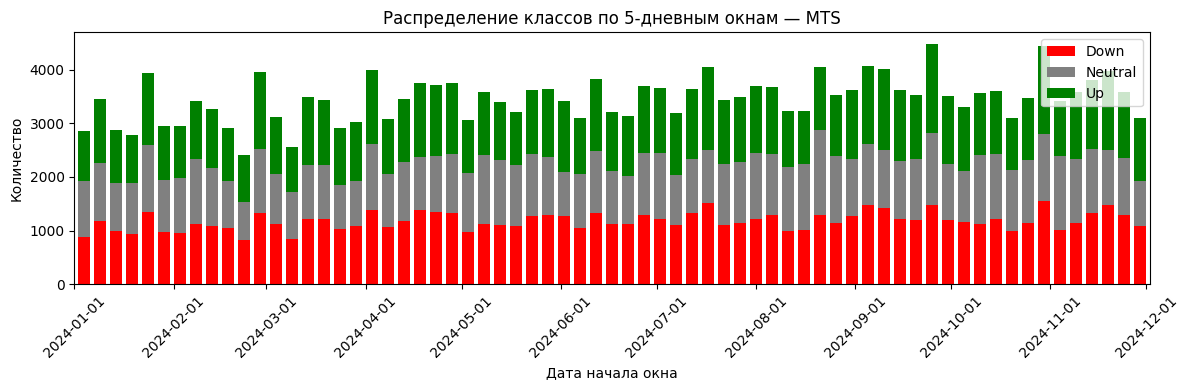

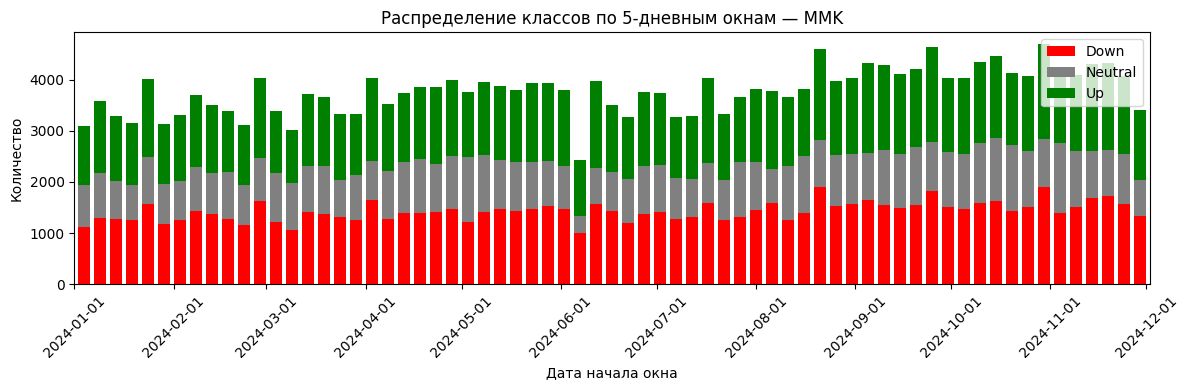

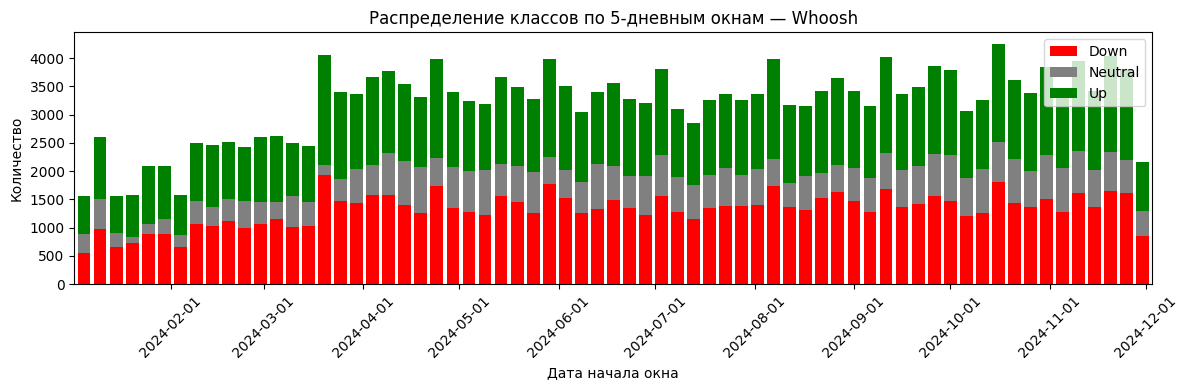

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt

def compute_direction_both(df):
    df = df.copy()
    df['close_next'] = df['close'].shift(-1)
    df['direction_both'] = (df['close_next'] > df['close']).astype(int) - (df['close_next'] < df['close']).astype(int)
    return df.drop(columns=['close_next'])

def plot_class_distribution(df, company_name):
    df['utc'] = pd.to_datetime(df['utc'])
    df = compute_direction_both(df)
    df = df.dropna(subset=['direction_both'])

    df['period'] = df['utc'].dt.floor('1D')
    start = df['period'].min()
    df['bin'] = ((df['period'] - start) // pd.Timedelta(days=5)).astype(int)
    
    summary = df.groupby('bin')['direction_both'].value_counts().unstack(fill_value=0)
    summary = summary.rename(columns={-1: 'Down', 0: 'Neutral', 1: 'Up'})
    
    bin_dates = [start + pd.Timedelta(days=5 * i) for i in summary.index]

    # Рисуем stacked bar chart с шириной 4 дня
    fig, ax = plt.subplots(figsize=(12, 4))
    width = pd.Timedelta(days=4)

    bar1 = ax.bar(bin_dates, summary['Down'], width=width, align='edge', label='Down', color='red')
    bar2 = ax.bar(bin_dates, summary['Neutral'], width=width, align='edge', 
                  bottom=summary['Down'], label='Neutral', color='gray')
    bar3 = ax.bar(bin_dates, summary['Up'], width=width, align='edge', 
                  bottom=summary['Down'] + summary['Neutral'], label='Up', color='green')

    # for i, (d, n, u) in enumerate(zip(summary['Down'], summary['Neutral'], summary['Up'])):
    #     total = d + n + u
    #     x = bin_dates[i] + pd.Timedelta(days=2)  # центр бара
    #     if total > 0:
    #         ax.text(x, d / 2, f'{d / total:.0%}', color='black', ha='center', va='center', fontsize=4, fontweight='bold')
    #         ax.text(x, d + n / 2, f'{n / total:.0%}', color='black', ha='center', va='center', fontsize=4, fontweight='bold')
    #         ax.text(x, d + n + u / 2, f'{u / total:.0%}', color='black', ha='center', va='center', fontsize=4, fontweight='bold')

    ax.set_title(f'Распределение классов по 5-дневным окнам — {company_name}')
    ax.set_xlabel('Дата начала окна')
    ax.set_ylabel('Количество')
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.set_xlim([bin_dates[0] - pd.Timedelta(days=1), bin_dates[-1] + pd.Timedelta(days=5)])
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig


# Пример использования:
companies = ['Gazprom', 'Sber', 'MTS', 'MMK', 'Whoosh']
figs = []

for name in companies:
    df = FinData(f'../../datasets/{name}_1_min.csv').df
    df = df[(df['utc'] >= '2024-01-01') & (df['utc'] < '2024-12-01')]
    fig = plot_class_distribution(df, name)
    figs.append(fig)


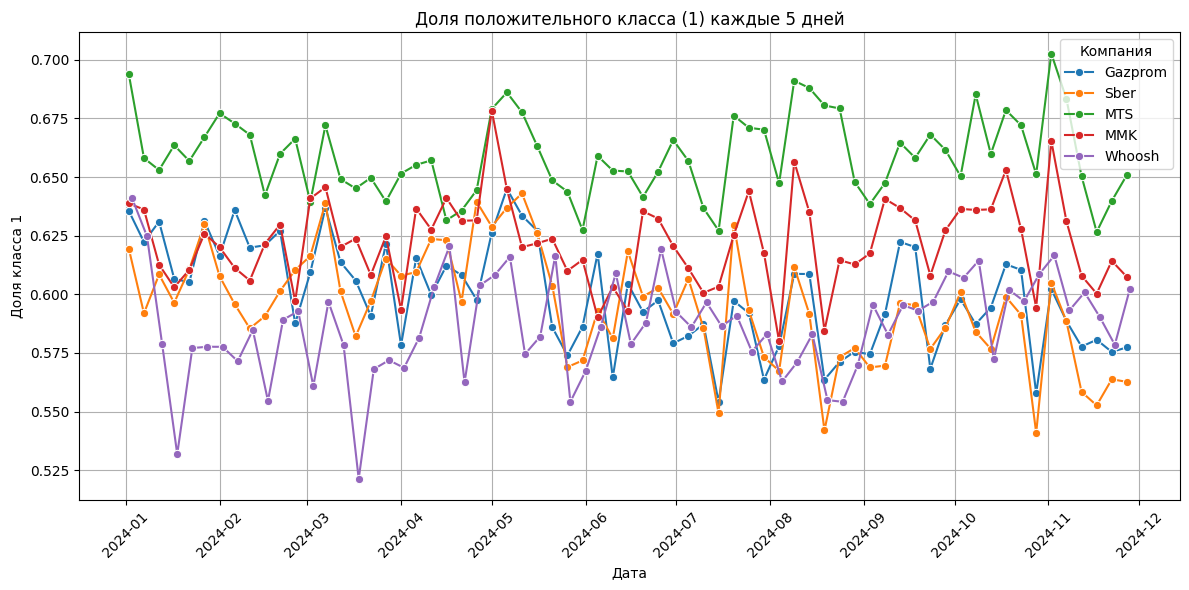

In [98]:
from pathlib import Path

# Параметры
companies = ['Gazprom', 'Sber', 'MTS', 'MMK', 'Whoosh']
path_base = Path('../../datasets')
cutoff_time_1 = dt.datetime(2024, 1, 1)
cutoff_time_2 = dt.datetime(2024, 12, 1)
window_size = pd.Timedelta(days=5)

# Результаты
all_balances = []

for company in companies:
    data = FinData(path_base / f'{company}_1_min.csv')
    data.restrict_time_down(cutoff_time_1)
    data.restrict_time_up(cutoff_time_2)
    
    df = data.df[['utc', 'direction_binary_1']].copy()
    df = df.set_index('utc').sort_index()

    # Резэмплируем по 5 дням: считаем среднее (будет ≈ доля единиц)
    balance = df['direction_binary_1'].resample(window_size).mean().reset_index()
    balance['company'] = company
    all_balances.append(balance)

# Объединяем в один DataFrame
balance_df = pd.concat(all_balances)

# Визуализация
plt.figure(figsize=(12, 6))
sns.lineplot(data=balance_df, x='utc', y='direction_binary_1', hue='company', marker='o')
plt.title('Доля положительного класса (1) каждые 5 дней')
plt.ylabel('Доля класса 1')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title='Компания')
plt.show()

In [99]:
data = pd.read_csv('Gazprom_model_1.csv')
data

,utc,open,close,predicted_proba
0,2024-02-01 07:00:00,166.71,166.65,0.339327
1,2024-02-01 07:01:00,166.64,166.74,0.352016
2,2024-02-01 07:02:00,166.70,166.58,0.373804
3,2024-02-01 07:03:00,166.55,166.67,0.370734
4,2024-02-01 07:04:00,166.67,166.65,0.443187
...,...,...,...,...
284744,2024-12-31 20:45:00,132.40,132.70,0.086837
284745,2024-12-31 20:46:00,132.70,132.71,0.120502
284746,2024-12-31 20:47:00,132.71,132.70,0.124401
284747,2024-12-31 20:48:00,132.71,132.71,0.135099


In [100]:
threshold = 0.5

In [101]:
data['target'] = (data['close'].shift(-1) > data['close']).astype(int)

data['pred'] = (data['predicted_proba'] > threshold).astype(int)
# (self.df['close'].shift(-1) > self.df['close']).astype('int')

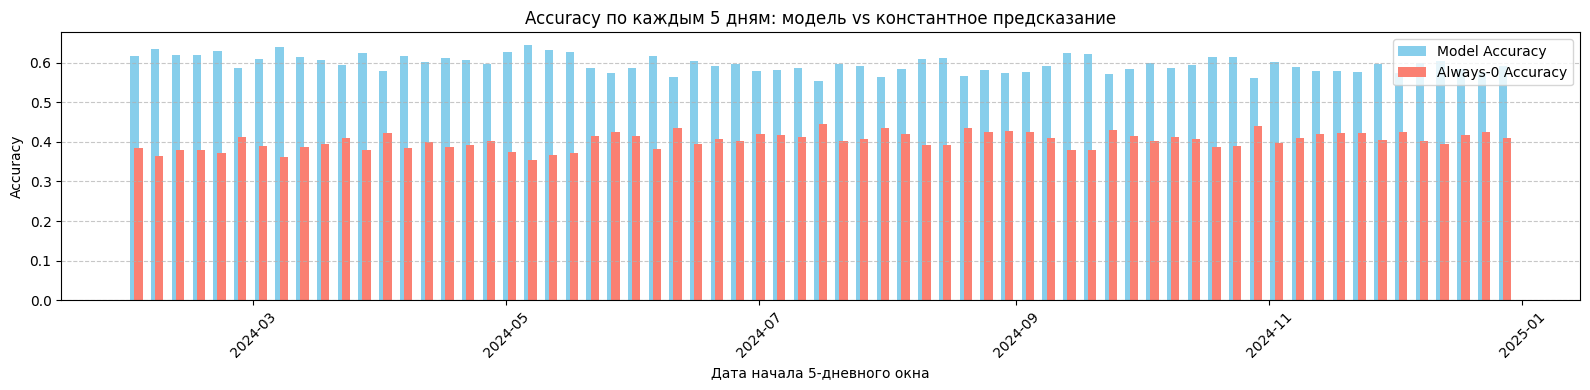

In [272]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_short.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчёта accuracy модели и accuracy "всегда 0"
def compute_group_accuracy(group):
    acc_model = accuracy_score(group['target'], group['pred'])
    acc_dummy0 = accuracy_score(group['target'], [0] * len(group))
    return pd.Series({'accuracy_model': acc_model, 'accuracy_dummy0': acc_dummy0})

# Применяем по группам
grouped_accuracy = data.groupby('group_id').apply(compute_group_accuracy).reset_index()

# Добавим дату начала группы
grouped_accuracy['start_date'] = data.groupby('group_id')['utc'].min().values

# Строим barplot
plt.figure(figsize=(16, 4))
bar_width = 4  # Ширина одного столбца (в днях на оси X)

# Координаты по оси X
x = grouped_accuracy['start_date']

# Столбцы с accuracy модели (слева) и dummy (чуть правее)
plt.bar(x, grouped_accuracy['accuracy_model'], 
        width=2, label='Model Accuracy', color='skyblue', align='center')

plt.bar(x, grouped_accuracy['accuracy_dummy0'], 
        width=2, label='Always-0 Accuracy', color='salmon', align='edge')

# Подписи и оформление
plt.title('Accuracy по каждым 5 дням: модель vs константное предсказание')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


In [273]:
from sklearn.metrics import precision_score, recall_score

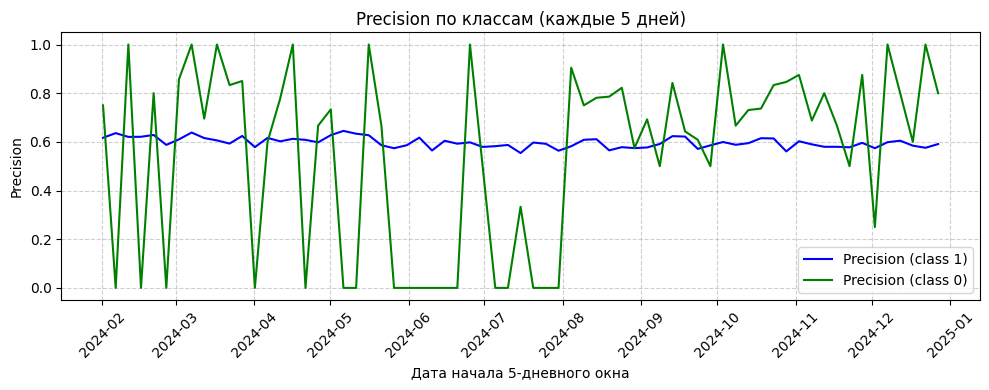

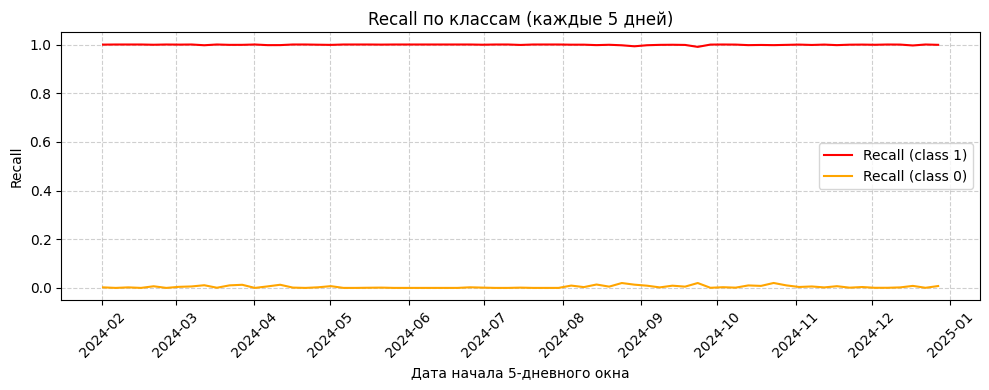

In [274]:
# Группировка по 5-дневным окнам
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчета precision и recall по классам
def compute_precision_recall(group):
    y_true = group['target']
    y_pred = group['pred']
    precision_1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision_0 = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    recall_1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_0 = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return pd.Series({
        'precision_1': precision_1,
        'precision_0': precision_0,
        'recall_1': recall_1,
        'recall_0': recall_0
    })

# Применяем по группам
metrics_by_group = data.groupby('group_id').apply(compute_precision_recall).reset_index()

# Добавим дату начала каждой группы
metrics_by_group['start_date'] = data.groupby('group_id')['utc'].min().values

# ----------------------- #
# 1. График Precision     #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_1'], label='Precision (class 1)', color='blue')
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_0'], label='Precision (class 0)', color='green')
plt.title('Precision по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Precision')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 2. График Recall        #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_1'], label='Recall (class 1)', color='red')
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_0'], label='Recall (class 0)', color='orange')
plt.title('Recall по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [275]:
merged = data

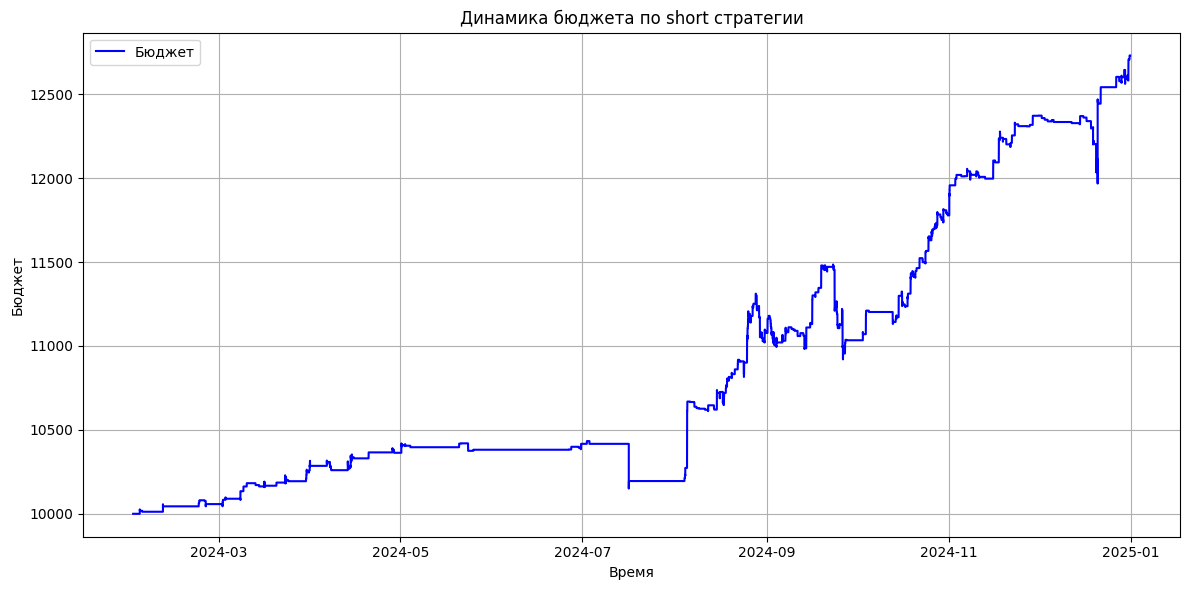

In [276]:
# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = df['pred']

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    # if signal == 1:  # Long
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         buy_cost = n_shares * price_now * (1 + commission_rate)
    #         sell_revenue = n_shares * price_next * (1 - commission_rate)
    #         budget += sell_revenue - buy_cost

    if signal == 0:  # Short
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            sell_proceeds = n_shares * price_now * (1 - commission_rate)
            buy_cost = n_shares * price_next * (1 + commission_rate)
            budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по short стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


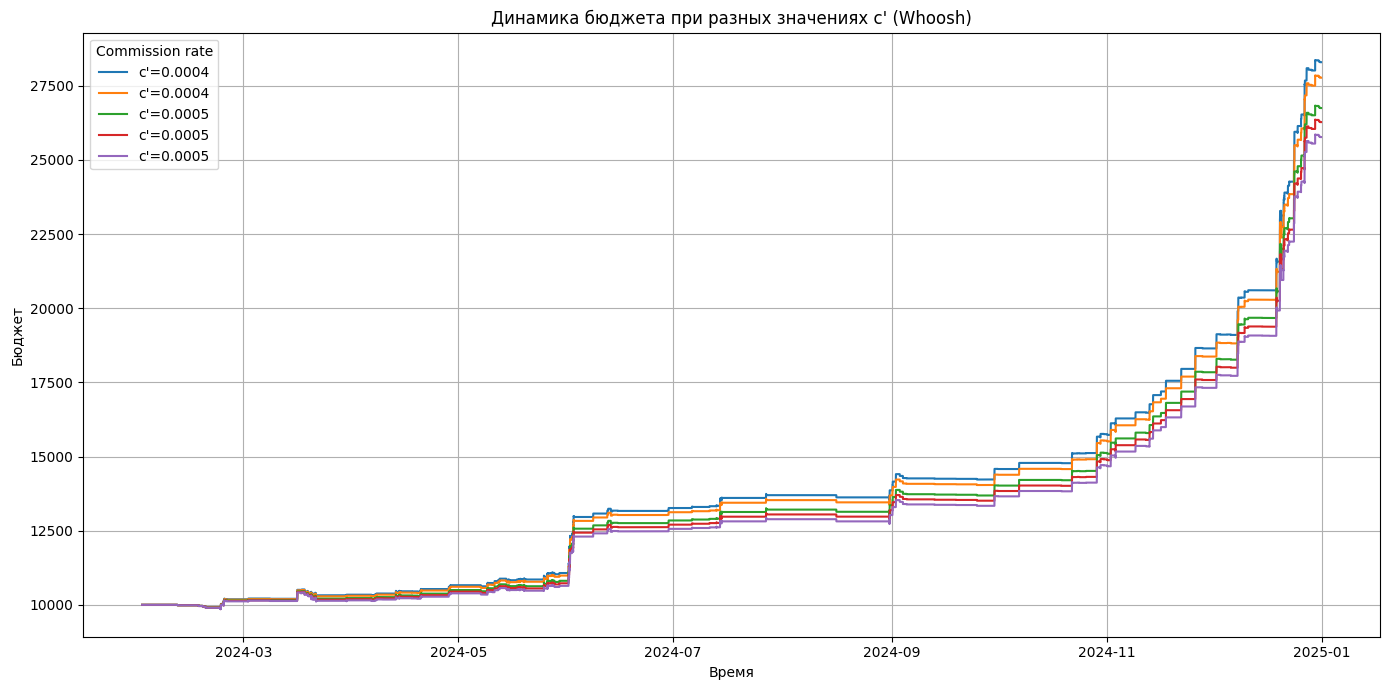

In [209]:
import matplotlib.pyplot as plt

# Параметры
initial_budget = 10000
commission_rates = [0.0004, 0.00042, 0.00046, 0.00048, 0.0005]

df['predicted_class'] = df['pred']

# Предполагается, что df содержит колонку predicted_class с сигналами (0 — short)
df['close_t+1'] = df['close'].shift(-1)
df = df.dropna()

plt.figure(figsize=(14, 7))

for rate in commission_rates:
    budget = initial_budget
    budget_history = [budget]
    timestamps = [df['utc'].iloc[0]]

    for i in range(len(df) - 1):
        row = df.iloc[i]
        next_row = df.iloc[i + 1]

        price_now = row['close']
        price_next = next_row['close']
        signal = row['predicted_class']

        if signal == 0:  # Short стратегия
            n_shares = int(budget // price_now)
            if n_shares > 0:
                sell_proceeds = n_shares * price_now * (1 - rate)
                buy_cost = n_shares * price_next * (1 + rate)
                budget += sell_proceeds - buy_cost

        budget_history.append(budget)
        timestamps.append(next_row['utc'])

    plt.plot(timestamps, budget_history, label=f"c\'={rate:.4f}")

# Оформление графика
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title("Динамика бюджета при разных значениях c\' (Whoosh)")
plt.grid(True)
plt.legend(title='Commission rate')
plt.tight_layout()
plt.show()


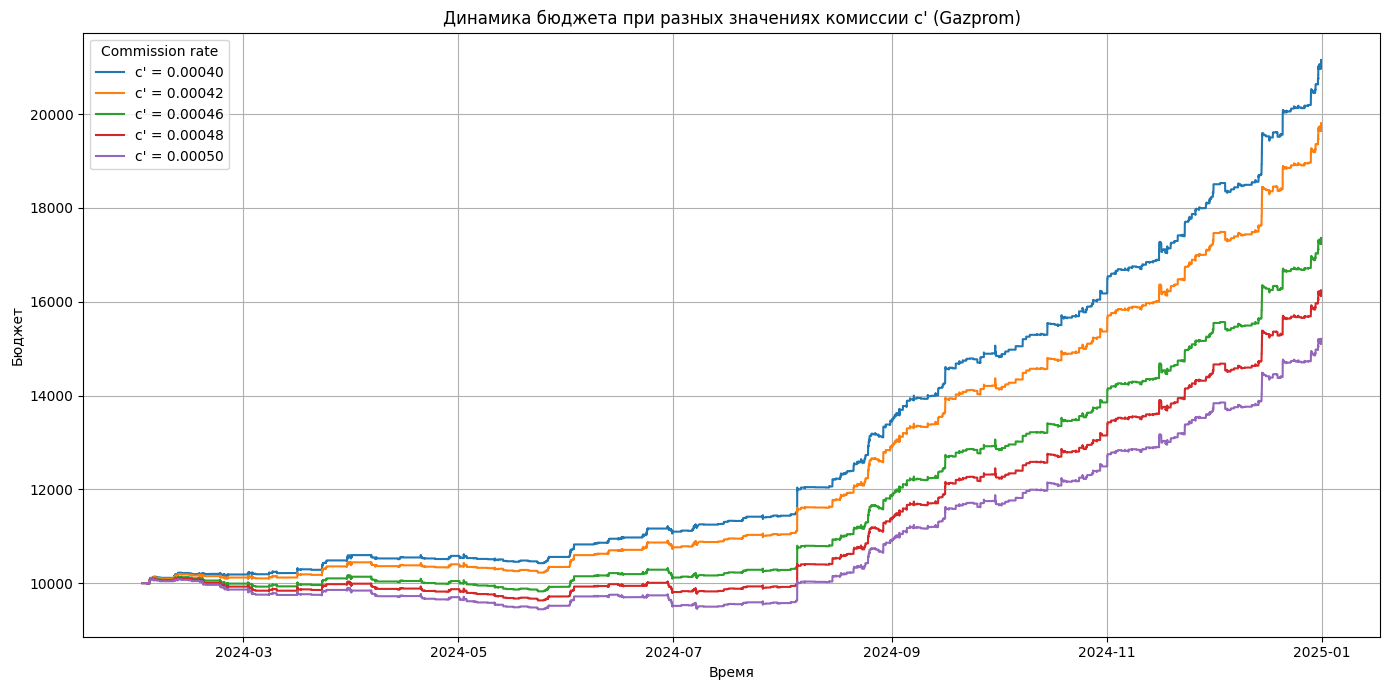

In [179]:
import matplotlib.pyplot as plt

# Параметры
initial_budget = 10000
commission_rates = [0.0004, 0.00042, 0.00046, 0.00048, 0.0005]

df['predicted_class'] = df['pred']
df['close_t+1'] = df['close'].shift(-1)
df = df.dropna()

plt.figure(figsize=(14, 7))

for rate in commission_rates:
    budget = initial_budget
    budget_history = [budget]
    timestamps = [df['utc'].iloc[0]]

    for i in range(len(df) - 1):
        row = df.iloc[i]
        next_row = df.iloc[i + 1]

        price_now = row['close']
        price_next = next_row['close']
        signal = row['predicted_class']

        if signal == 1:  # Long
            n_shares = int(budget // price_now)
            if n_shares > 0:
                buy_cost = n_shares * price_now * (1 + rate)
                sell_revenue = n_shares * price_next * (1 - rate)
                budget += sell_revenue - buy_cost

        budget_history.append(budget)
        timestamps.append(next_row['utc'])

    plt.plot(timestamps, budget_history, label=f"c' = {rate:.5f}")

# Оформление графика
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title("Динамика бюджета при разных значениях комиссии c' (Gazprom)")
plt.grid(True)
plt.legend(title='Commission rate')
plt.tight_layout()
plt.show()


In [213]:
data = FinData('../../datasets/Gazprom_1_min.csv')
data.df

,utc,open,close,high,low,volume,direction_binary_0,direction_binary_1
0,2018-03-07 18:34:00,138.45,138.48,138.48,138.41,733,0,0
1,2018-03-07 18:35:00,138.42,138.44,138.48,138.40,1262,0,0
2,2018-03-07 18:36:00,138.38,138.36,138.41,138.36,893,1,1
3,2018-03-07 18:37:00,138.36,138.40,138.43,138.36,1870,0,0
4,2018-03-07 18:38:00,138.36,138.36,138.46,138.31,8735,0,1
...,...,...,...,...,...,...,...,...
1375313,2024-12-31 20:45:00,132.40,132.70,132.70,132.40,4,1,1
1375314,2024-12-31 20:46:00,132.70,132.71,132.71,132.70,15,0,0
1375315,2024-12-31 20:47:00,132.71,132.70,132.71,132.70,46,1,1
1375316,2024-12-31 20:48:00,132.71,132.71,132.71,132.70,78,0,1


2025-05-30 09:49:32,419 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-30 09:49:32,433 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-30 09:49:32,597 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-30 09:49:32,620 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


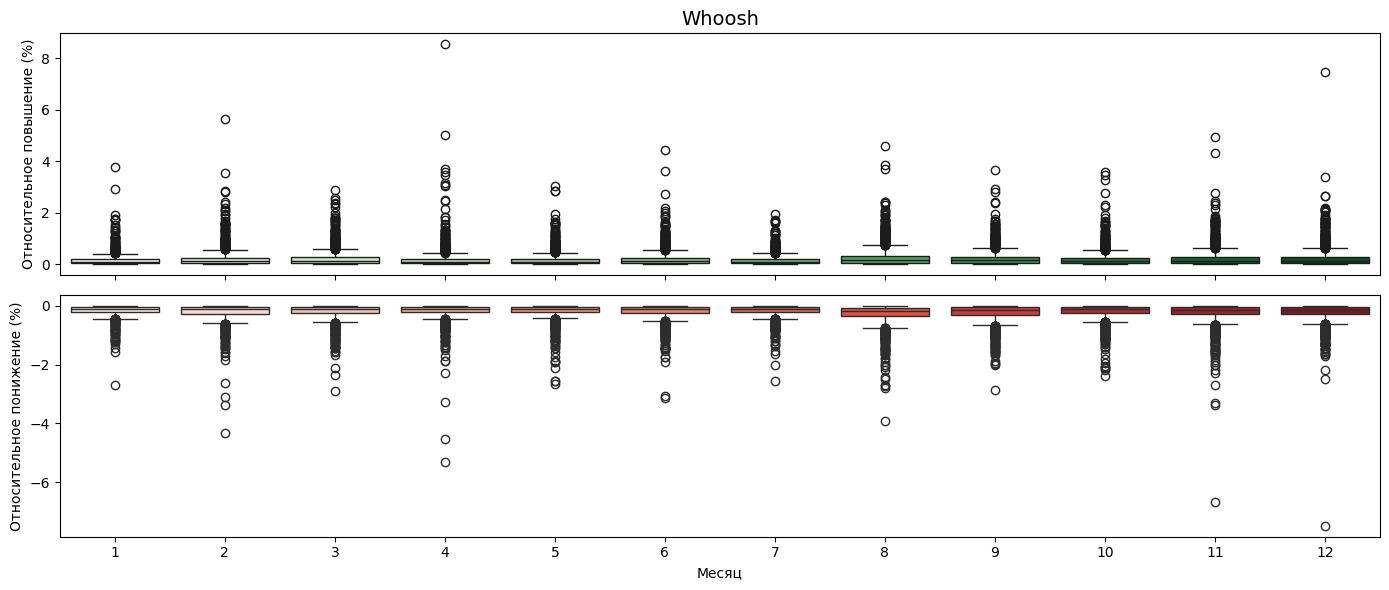

In [232]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
data = FinData('../../datasets/Whoosh_10_min.csv').df

# Преобразуем колонку 'utc' в datetime
data['utc'] = pd.to_datetime(data['utc'])

# Считаем относительное изменение цены в процентах
data['close_shift'] = data['close'].shift(-1)
data['delta_close_pct'] = (data['close_shift'] - data['close']) / data['close'] * 100

# Добавляем колонку с месяцем
data['month'] = data['utc'].dt.month

# Фильтруем повышения и понижения
increases = data[data['delta_close_pct'] > 0]
decreases = data[data['delta_close_pct'] < 0]

# Строим два графика (2 строки, 1 колонка)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# График для относительных повышений
sns.boxplot(
    ax=axes[0],
    x='month',
    y='delta_close_pct',
    data=increases,
    palette='Greens'
)
axes[0].set_title('Whoosh', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('Относительное повышение (%)')

# График для относительных понижений
sns.boxplot(
    ax=axes[1],
    x='month',
    y='delta_close_pct',
    data=decreases,
    palette='Reds'
)
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Относительное понижение (%)')

plt.tight_layout()
plt.show()


2025-05-30 09:59:19,688 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-30 09:59:20,042 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


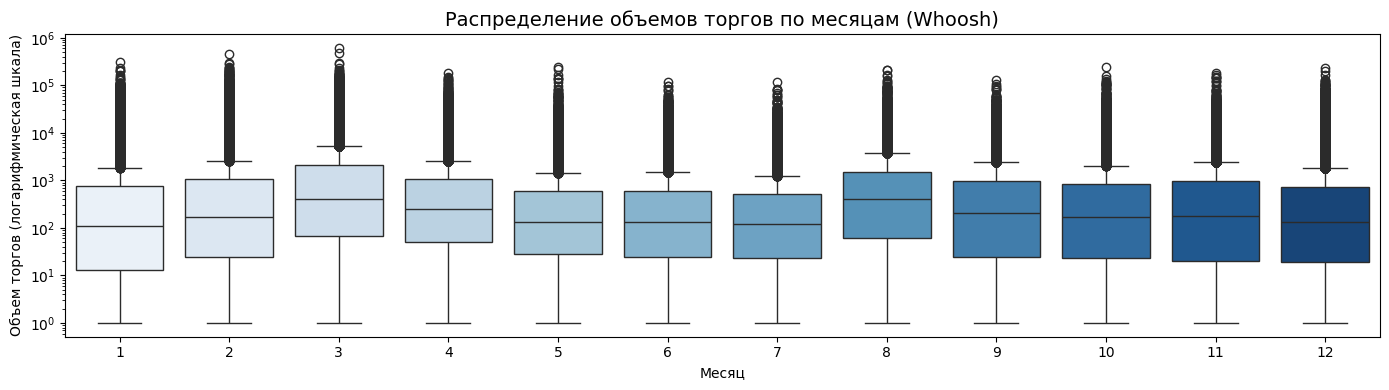

In [241]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
data = FinData('../../datasets/Whoosh_1_min.csv').df

# Преобразуем колонку 'utc' в datetime
data['utc'] = pd.to_datetime(data['utc'])

# Добавляем колонку с месяцем
data['month'] = data['utc'].dt.month

# Строим boxplot для объемов торгов с логарифмической шкалой
plt.figure(figsize=(14, 4))
ax = sns.boxplot(
    x='month',
    y='volume',
    data=data,
    palette='Blues'
)
ax.set_yscale('log')

plt.title('Распределение объемов торгов по месяцам (Whoosh)', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Объем торгов (логарифмическая шкала)')

plt.tight_layout()
plt.show()


In [256]:
data = FinData('../../datasets/Gazprom_1_min.csv')

data.restrict_time_down(dt.datetime(2024, 1, 1))

data.insert_news_features(news_df='../../text_datasets/markettwits_with_hashtags.csv')

data.df

,utc,open,close,high,low,volume,direction_binary_0,direction_binary_1,new_label,time_from_new
0,2024-01-02 07:17:00,160.33,159.42,160.33,159.42,162,1,1,0,None
1,2024-01-02 07:18:00,160.29,160.28,160.29,159.42,56,0,0,0,None
2,2024-01-02 07:19:00,159.45,159.48,160.28,159.45,108,1,1,0,None
3,2024-01-02 07:20:00,159.48,160.17,160.19,159.47,54,0,0,0,None
4,2024-01-02 07:21:00,160.00,160.14,160.16,159.90,72,1,1,0,None
...,...,...,...,...,...,...,...,...,...,...
306472,2024-12-31 20:45:00,132.40,132.70,132.70,132.40,4,1,1,0,1433
306473,2024-12-31 20:46:00,132.70,132.71,132.71,132.70,15,0,0,0,1434
306474,2024-12-31 20:47:00,132.71,132.70,132.71,132.70,46,1,1,0,1435
306475,2024-12-31 20:48:00,132.71,132.71,132.71,132.70,78,0,1,0,1436


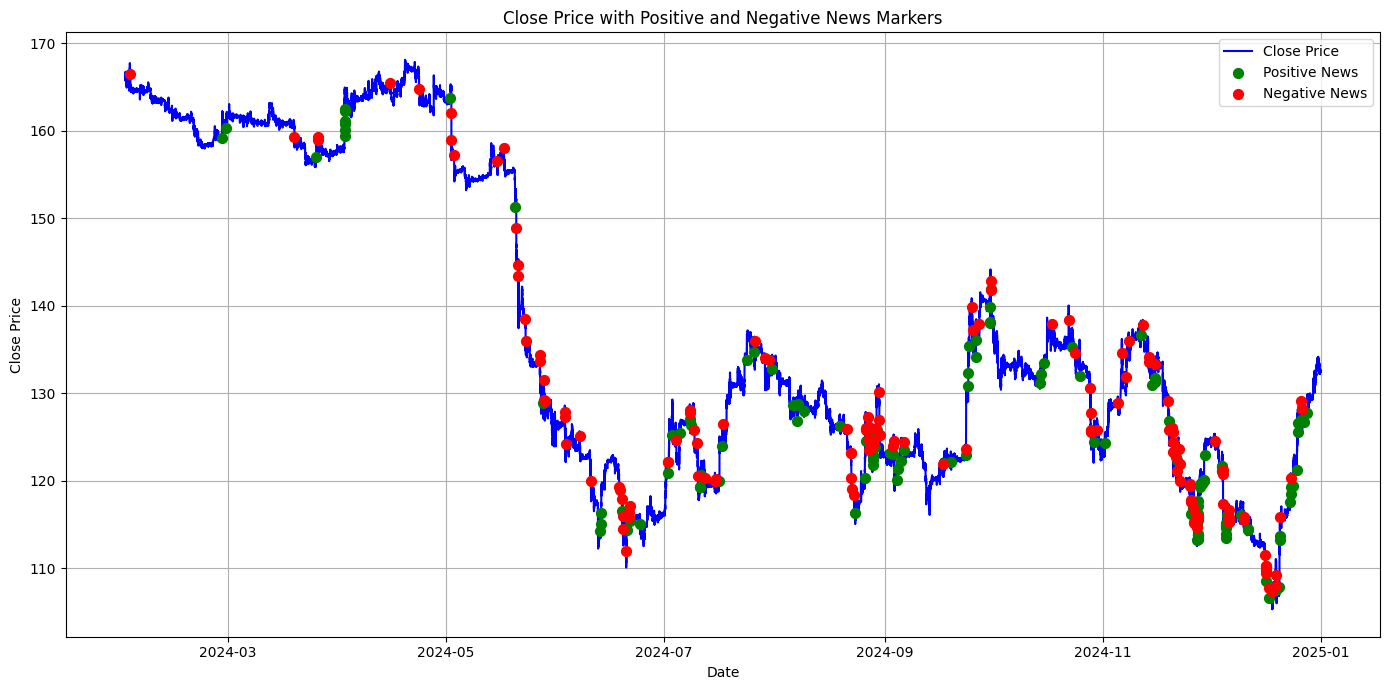

In [260]:
import pandas as pd
import matplotlib.pyplot as plt

# === Параметры стратегии ===
initial_budget = 10000
threshold = 0.5
commission_rate = 0.0004

# === Загрузим данные ===
# 1. С предсказаниями
df = pd.read_csv('Gazprom_long.csv')
df['utc'] = pd.to_datetime(df['utc'])
df = df.sort_values('utc')

# 2. С новостями
data = FinData('../../datasets/Gazprom_1_min.csv')
data.restrict_time_down(pd.Timestamp('2024-01-01'))
data.insert_news_features(news_df='../../text_datasets/markettwits_with_hashtags.csv')
news_df = data.df.copy()
news_df['utc'] = pd.to_datetime(news_df['utc'])
news_df = news_df.sort_values('utc')

# === Объединим по времени ===
merged = pd.merge_asof(df, news_df[['utc', 'new_label', 'time_from_new']], on='utc', direction='backward')
merged = merged.fillna({'new_label': 0, 'time_from_new': -1})  # если нет новости — 0, -1

# === Добавим целевую переменную и предсказанный класс ===
merged['target'] = (merged['close'].shift(-1) >= merged['close']).astype(int)
merged['predicted_class'] = (merged['predicted_proba'] > threshold).astype(int)
merged['close_t+1'] = merged['close'].shift(-1)

# === График цены закрытия ===
plt.figure(figsize=(14, 7))
plt.plot(merged['utc'], merged['close'], label='Close Price', color='blue')

# === Добавляем точки с новостями ===
# Только для тех моментов, когда новость вышла именно сейчас (time_from_new == 0)
news_moments = merged[(merged['time_from_new'] == 0) & (merged['new_label'] != 0)]

# Позитивные новости — зелёные точки
pos_news = news_moments[news_moments['new_label'] == 1]
plt.scatter(pos_news['utc'], pos_news['close'], color='green', label='Positive News', s=50, zorder=5)

# Негативные новости — красные точки
neg_news = news_moments[news_moments['new_label'] == -1]
plt.scatter(neg_news['utc'], neg_news['close'], color='red', label='Negative News', s=50, zorder=5)

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price with Positive and Negative News Markers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


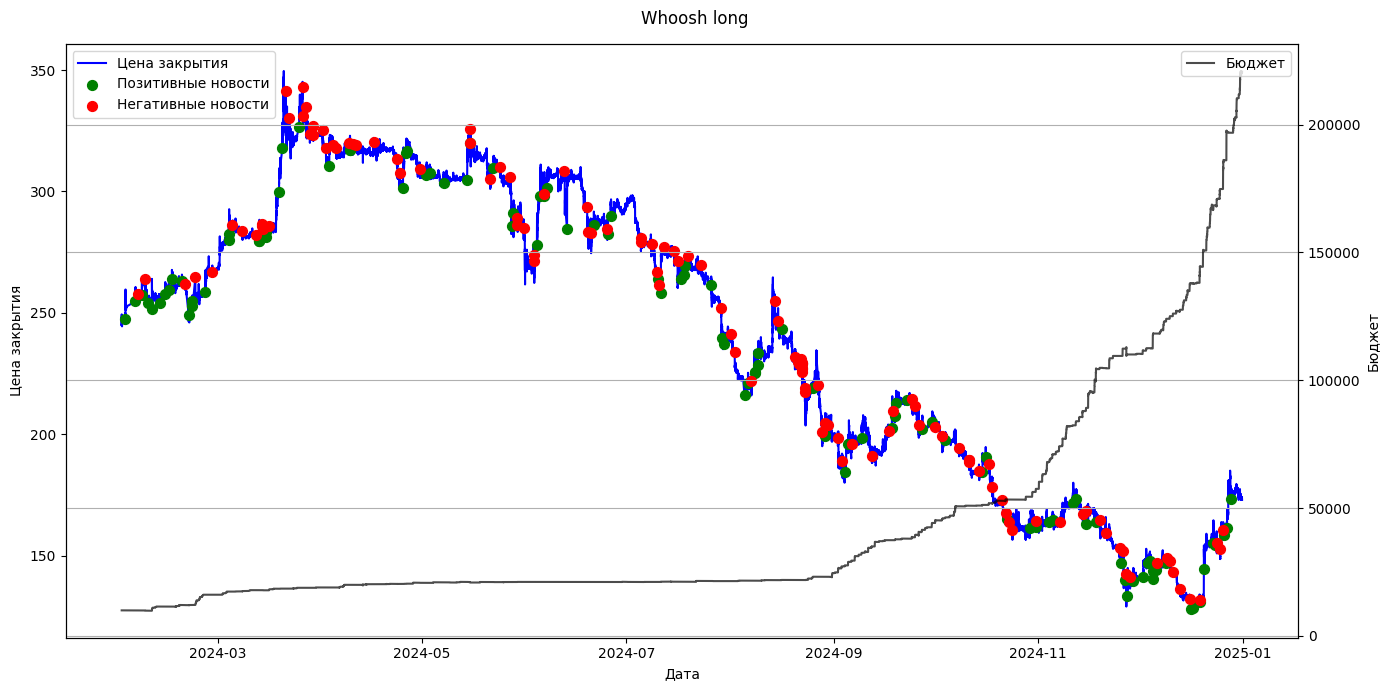

In [284]:
import pandas as pd
import matplotlib.pyplot as plt

# === Параметры стратегии ===
initial_budget = 10000
threshold = 0.5
commission_rate = 0.0004

# === Загрузим данные ===
# 1. С предсказаниями
df = pd.read_csv('Whoosh_long.csv')
df['utc'] = pd.to_datetime(df['utc'])
df = df.sort_values('utc')

# 2. С новостями
data = FinData('../../datasets/Whoosh_1_min.csv')
data.restrict_time_down(pd.Timestamp('2024-01-01'))
data.insert_news_features(news_df='../../text_datasets/markettwits_with_hashtags.csv')
news_df = data.df.copy()
news_df['utc'] = pd.to_datetime(news_df['utc'])
news_df = news_df.sort_values('utc')

# === Объединим по времени ===
merged = pd.merge_asof(df, news_df[['utc', 'new_label', 'time_from_new']], on='utc', direction='backward')
merged = merged.fillna({'new_label': 0, 'time_from_new': -1})

merged['predicted_class'] = (merged['predicted_proba'] > threshold).astype(int)
merged['close_t+1'] = merged['close'].shift(-1)

# === Стратегия торговли ===
budget = initial_budget
budget_history = [budget]
timestamps = [merged['utc'].iloc[0]]

for i in range(len(merged) - 1):
    row = merged.iloc[i]
    next_row = merged.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 1:
        n_shares = int(budget // price_now)
        if n_shares > 0:
            buy_cost = n_shares * price_now * (1 + commission_rate)
            sell_revenue = n_shares * price_next * (1 - commission_rate)
            budget += sell_revenue - buy_cost

    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# === График цены закрытия и бюджета с двумя осями Y ===
fig, ax1 = plt.subplots(figsize=(14, 7))

# Первая ось — цена закрытия
ax1.plot(merged['utc'], merged['close'], label='Цена закрытия', color='blue')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Цена закрытия', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Добавляем точки с новостями (time_from_new == 0)
news_moments = merged[(merged['time_from_new'] == 0) & (merged['new_label'] != 0)]

# Позитивные новости — зелёные точки
pos_news = news_moments[news_moments['new_label'] == 1]
ax1.scatter(pos_news['utc'], pos_news['close'], color='green', label='Позитивные новости', s=50, zorder=5)

# Негативные новости — красные точки
neg_news = news_moments[news_moments['new_label'] == -1]
ax1.scatter(neg_news['utc'], neg_news['close'], color='red', label='Негативные новости', s=50, zorder=5)

# Вторая ось — бюджет
ax2 = ax1.twinx()
ax2.plot(timestamps, budget_history, label='Бюджет', color='black', alpha=0.7)
ax2.set_ylabel('Бюджет', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Заголовок и легенда
fig.suptitle('Whoosh long')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()


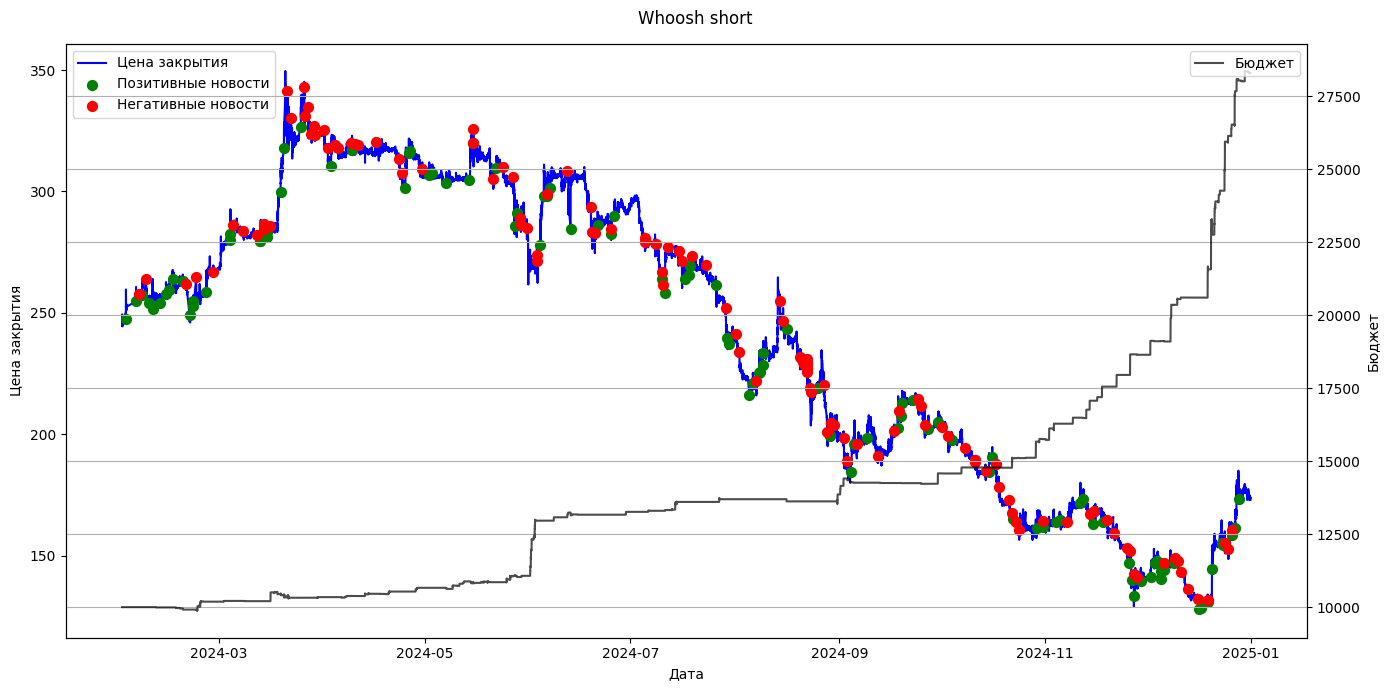

In [285]:
import pandas as pd
import matplotlib.pyplot as plt

# === Параметры стратегии ===
initial_budget = 10000
threshold = 0.5
commission_rate = 0.0004

# === Загрузим данные ===
# 1. С предсказаниями
df = pd.read_csv('Whoosh_short.csv')
df['utc'] = pd.to_datetime(df['utc'])
df = df.sort_values('utc')

# 2. С новостями
data = FinData('../../datasets/Whoosh_1_min.csv')
data.restrict_time_down(pd.Timestamp('2024-01-01'))
data.insert_news_features(news_df='../../text_datasets/markettwits_with_hashtags.csv')
news_df = data.df.copy()
news_df['utc'] = pd.to_datetime(news_df['utc'])
news_df = news_df.sort_values('utc')

# === Объединим по времени ===
merged = pd.merge_asof(df, news_df[['utc', 'new_label', 'time_from_new']], on='utc', direction='backward')
merged = merged.fillna({'new_label': 0, 'time_from_new': -1})

merged['predicted_class'] = (merged['predicted_proba'] > threshold).astype(int)
merged['close_t+1'] = merged['close'].shift(-1)

# === Стратегия торговли ===
budget = initial_budget
budget_history = [budget]
timestamps = [merged['utc'].iloc[0]]

for i in range(len(merged) - 1):
    row = merged.iloc[i]
    next_row = merged.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 0:  # Short
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            sell_proceeds = n_shares * price_now * (1 - commission_rate)
            buy_cost = n_shares * price_next * (1 + commission_rate)
            budget += sell_proceeds - buy_cost

    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# === График цены закрытия и бюджета с двумя осями Y ===
fig, ax1 = plt.subplots(figsize=(14, 7))

# Первая ось — цена закрытия
ax1.plot(merged['utc'], merged['close'], label='Цена закрытия', color='blue')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Цена закрытия', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Добавляем точки с новостями (time_from_new == 0)
news_moments = merged[(merged['time_from_new'] == 0) & (merged['new_label'] != 0)]

# Позитивные новости — зелёные точки
pos_news = news_moments[news_moments['new_label'] == 1]
ax1.scatter(pos_news['utc'], pos_news['close'], color='green', label='Позитивные новости', s=50, zorder=5)

# Негативные новости — красные точки
neg_news = news_moments[news_moments['new_label'] == -1]
ax1.scatter(neg_news['utc'], neg_news['close'], color='red', label='Негативные новости', s=50, zorder=5)

# Вторая ось — бюджет
ax2 = ax1.twinx()
ax2.plot(timestamps, budget_history, label='Бюджет', color='black', alpha=0.7)
ax2.set_ylabel('Бюджет', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Заголовок и легенда
fig.suptitle('Whoosh short')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()
